## Step 0: Get your packages in order.

In [4]:
!pip install SimpleITK # This is a special library for visualising medical images.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 9.6 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sklearn as skl
import SimpleITK as sitk
import tensorflow as tf
from tensorflow import keras


# 1. Download and Load the Training, Test and Validation Datasets

Data source: [BOston Neonatal Brain Injury Data](https://zenodo.org/records/10602767)

### *A Note on the Training Data* ###

The data consists of a special type of preprocessed MRI images, known as ADC maps.

*ADC: Apparent Diffusion Coefficient*
- It is a measure of the magnitude of diffusion (or movement) of water molecules across brain tissues.

- This molecular movement can be restricted due to structural damage in the brain, such as tumours or lesions.

- Areas where this happens tend to appear noticeably darker than surrounding areas on MRI images.

- These darker areas can help doctors to determine where these lesions or tumours could be located on the brain.

The ADC maps in the dataset have been categorised into three groups.

The first group contains raw, unedited, unprocessed images.

The second group comprises ADC maps that have undergone Z-score normalisation. This has been done to account for the fact that, under healthy conditions, different areas of the brain have different movement patterns of water molecules.

 So, Z-score normalisation is required to ensure that the movement of water molecules is compared across brain regions, according to each specific region's healthy baseline for molecular movement.

 The third group comprises images where the brain lesions have been manually annotated by medical experts.

 More information can be found on these pages:

 [Bao et al., 2023](https://www.biorxiv.org/content/10.1101/2023.06.30.546841v1.full)

 [Radiopaedia - Apparent Diffusion Coefficient](https://radiopaedia.org/articles/apparent-diffusion-coefficient-1)


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!unzip -q /content/drive/MyDrive/CSE602_Project_Data/train_data.zip

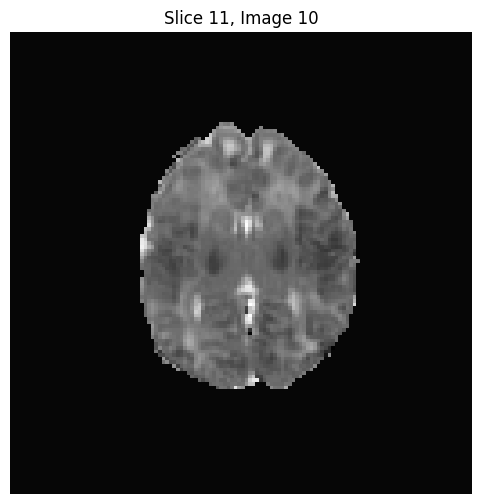

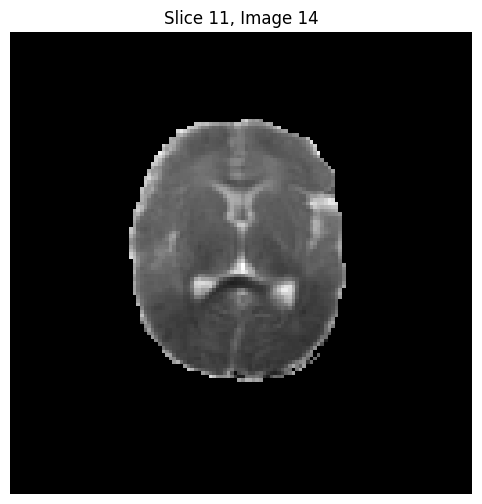

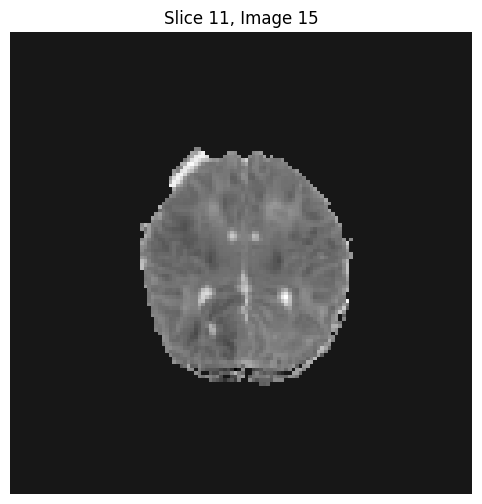

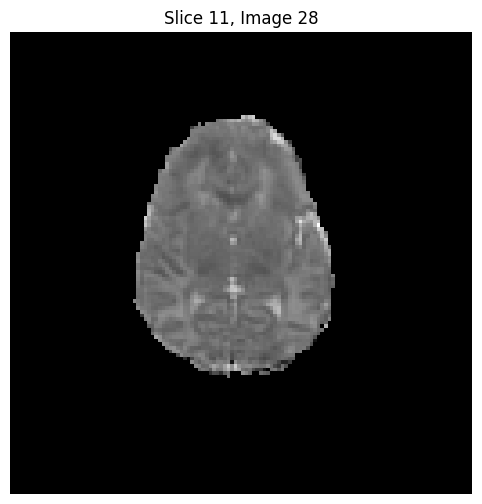

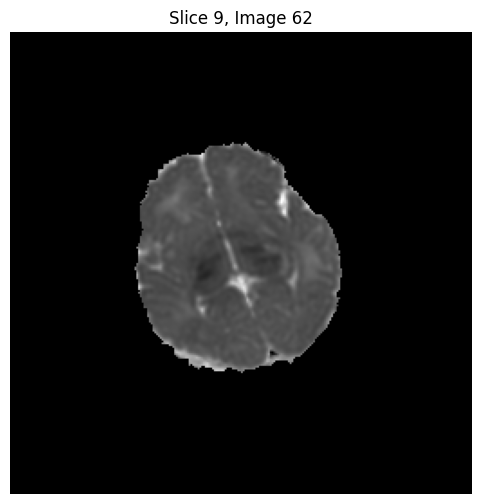

In [6]:
#Some basic EDA; we read in and visualise the first five raw ADC maps to get a glimpse of the data we'll be dealing with.


data_dir = '/content/BONBID2023_Train'

for i in [10, 14, 15, 28, 62]:
  train_image = sitk.ReadImage(f"{data_dir}/1ADC_ss/MGHNICU_0{i}-VISIT_01-ADC_ss.mha")
  train_array = sitk.GetArrayFromImage(train_image)
  mid_slice = train_array.shape[0] // 2

  plt.figure(figsize=(8, 6))
  plt.imshow(train_array[mid_slice, :, :], cmap = 'gray')
  plt.title(f"Slice {mid_slice}, Image {i}")
  plt.axis('off')
  plt.show()

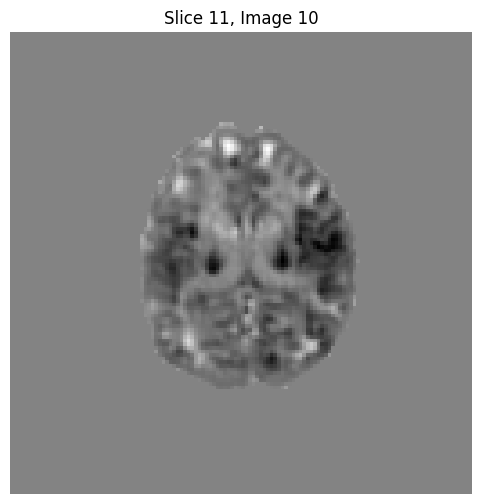

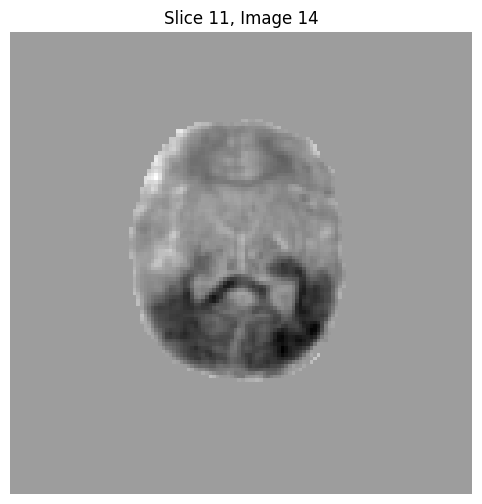

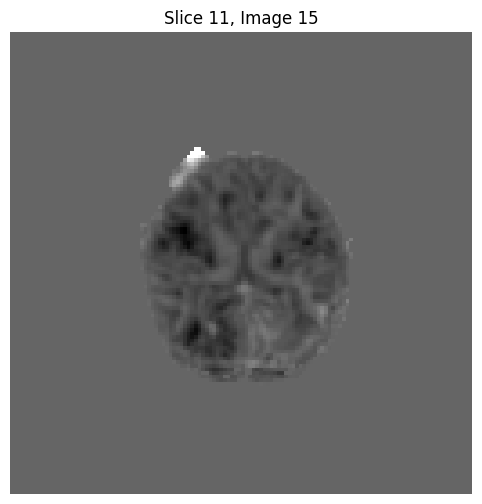

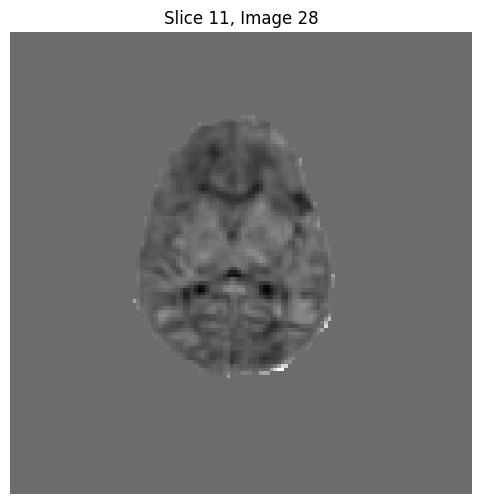

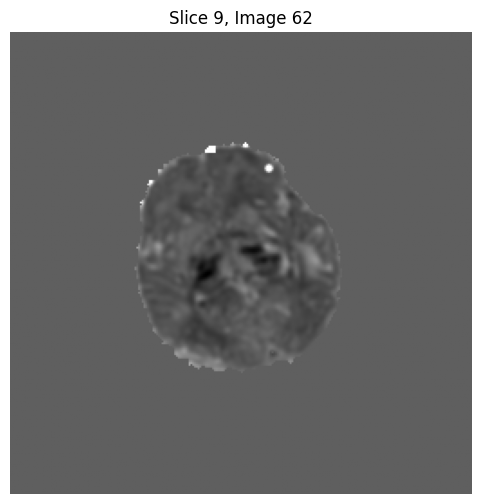

In [7]:
# We do the same for the Z-score normalised ADC maps...

for i in [10, 14, 15, 28, 62]:
  train_image = sitk.ReadImage(f"{data_dir}/2Z_ADC/Zmap_MGHNICU_0{i}-VISIT_01-ADC_smooth2mm_clipped10.mha")
  train_array = sitk.GetArrayFromImage(train_image)
  mid_slice = train_array.shape[0] // 2

  plt.figure(figsize=(8, 6))
  plt.imshow(train_array[mid_slice, :, :], cmap = 'gray')
  plt.title(f"Slice {mid_slice}, Image {i}")
  plt.axis('off')
  plt.show()

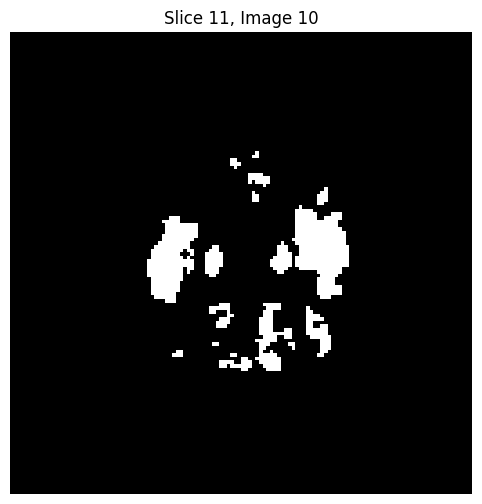

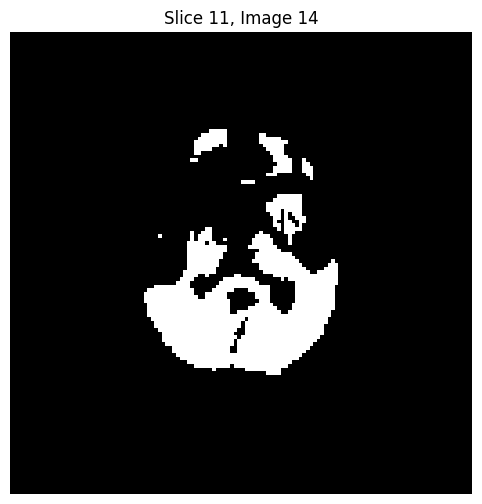

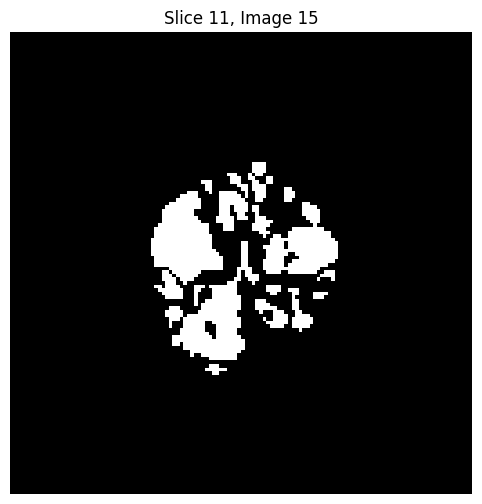

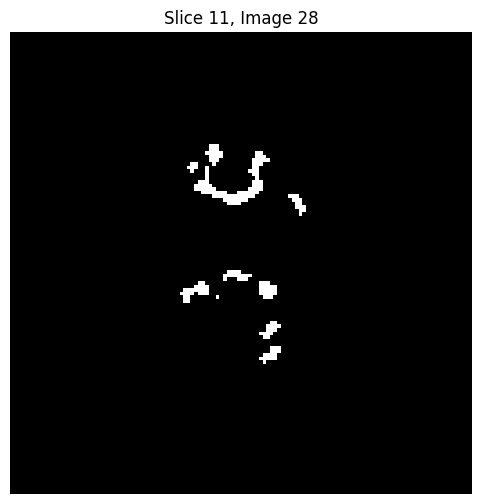

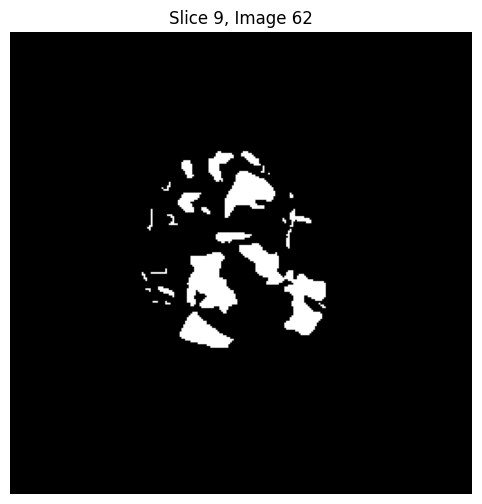

In [8]:
# ...and for the images with brain lesions annotated by experts.
for i in [10, 14, 15, 28, 62]:
  train_image = sitk.ReadImage(f"{data_dir}/3LABEL/MGHNICU_0{i}-VISIT_01_lesion.mha")
  train_array = sitk.GetArrayFromImage(train_image)
  mid_slice = train_array.shape[0] // 2

  plt.figure(figsize=(8, 6))
  plt.imshow(train_array[mid_slice, :, :], cmap = 'gray')
  plt.title(f"Slice {mid_slice}, Image {i}")
  plt.axis('off')
  plt.show()